В блокноте обучается модель для распознавания лиц на CE loss. Модель это предобученная ResNet18, у которой заменен последний слой классификации. Архив датасета был скопирован на гугл диск и картинки берутся оттуда.

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
root_dir = '/content/gdrive/MyDrive/Colab Notebooks/fr/'
checkpoint_dir = root_dir + 'checkpoints/CE/'
data_dir = 'aligned/'

In [ ]:
import os
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
!unzip -q '/content/gdrive/MyDrive/Colab Notebooks/fr/aligned.zip'

In [ ]:
!pip install albumentationsx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.4/551.4 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 101.9 MB/s eta 0:00:00
  Attempting uninstall: albucore
    Found existing installation: albucore 0.0.24
    Uninstalling albucore-0.0.24:
      Successfully uninstalled albucore-0.0.24
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
albumentations 2.0.8 requires albucore==0.0.24, but you have albucore 0.1.6 which is incompatible.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision.datasets import ImageFolder
import torchvision.models as models

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from tqdm import tqdm


Создание классов для датасетов.

In [ ]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

train_transform = A.Compose([
    A.HorizontalFlip(p=0.2),
    A.Affine(
        translate_percent={"x": (-0.02, 0.02), "y": (-0.02, 0.02)},
        scale=(0.95, 1.05),
        rotate=(-3, 3),
        balanced_scale=True, p=0.5),
    A.CoarseDropout(
        num_holes_range=(1, 3),
        hole_height_range=(10, 40),
        hole_width_range=(10, 40),
        p=0.3),
    A.ToGray(p=0.1),
    A.OneOf([
        A.RandomBrightnessContrast(p=1.0),
        A.RandomGamma(p=1.0),
    ], p=0.3),
    A.OneOf([
        A.MotionBlur(p=1.0),
        A.GaussianBlur(p=1.0),
        A.ImageCompression(quality_range=(75, 100), p=1.0),
    ], p=0.2),
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])

test_transform = A.Compose([
    A.Normalize(mean=mean, std=std),
    ToTensorV2(),
])


In [ ]:
def opencv_loader(path: str) -> np.ndarray:
    """Загружает изображение с помощью OpenCV в формате RGB для Albumentations."""
    img = cv2.imread(path)
    # По умолчанию cv2 читает в BGR, поэтому переводим в RGB
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


class AlbumentationsDataset(Dataset):
    def __init__(self, image_folder, transform=None):
        self.image_folder = image_folder
        self.transform = transform

    def __len__(self):
        return len(self.image_folder)

    def __getitem__(self, idx):
        # Получаем изображение и метку из ImageFolder
        image, label = self.image_folder[idx]

        # Если transform передан, применяем его
        if self.transform:
            image = self.transform(image=image)['image']

        return image, label


In [ ]:
BATCH_SIZE = 128

train_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}train/', loader=opencv_loader), transform=train_transform)
val_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}val/', loader=opencv_loader), transform=test_transform)
test_dataset = AlbumentationsDataset(ImageFolder(root=f'{data_dir}test/', loader=opencv_loader), transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
print(train_dataset.image_folder.classes)
print(train_dataset.image_folder.class_to_idx)

['10001', '10003', '10006', '10014', '10023', '10025', '10029', '1003', '10032', '10036', '10042', '10044', '10047', '10050', '10059', '10060', '10077', '1008', '10083', '10086', '10089', '10093', '10102', '10108', '10111', '10132', '10134', '1014', '10144', '10149', '10156', '10157', '10160', '10174', '10175', '1034', '1035', '1044', '1054', '1059', '1088', '1089', '1113', '1136', '1137', '114', '1154', '1170', '1175', '1180', '1181', '1187', '1194', '1198', '1210', '122', '1224', '1228', '1231', '1245', '1258', '1272', '1279', '1287', '1288', '1303', '1305', '1318', '1321', '1322', '1324', '1330', '1336', '1337', '1348', '1351', '1361', '1362', '1370', '1373', '1382', '1384', '1393', '1395', '14', '1410', '1411', '142', '1423', '1435', '1439', '1440', '1443', '1446', '1447', '1448', '1454', '1455', '1468', '147', '1472', '1474', '1481', '1489', '1490', '1493', '1496', '1519', '1538', '1544', '1549', '1550', '1569', '1578', '1581', '1588', '1601', '1603', '1604', '1614', '1634', '1639

Обучение модели.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
model = models.resnet18(weights='DEFAULT')
model.fc = nn.Linear(in_features=512, out_features=1000)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


In [ ]:
sum([len(p.ravel()) for p in model.parameters()])

11689512

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
criterion = nn.CrossEntropyLoss()

In [ ]:
train_loss_list = []
train_accuracy_list = []

val_loss_list = []
val_accuracy_list = []


In [ ]:
def fit_one_epoch(model, loader, criterion, optimizer):
    total_loss = 0.0
    correct_preds = 0.0
    total_samples = 0.0

    model.train()
    for batch_x, batch_y in tqdm(loader):
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_x.size(0)
        preds = logits.argmax(-1)
        correct_preds += (preds == batch_y).sum().item()
        total_samples += batch_x.size(0)

    mean_loss = total_loss / total_samples
    accuracy = correct_preds / total_samples

    return mean_loss, accuracy


def eval_one_epoch(model, loader, criterion):
    total_loss = 0.0
    correct_preds = 0.0
    total_samples = 0.0

    model.eval()
    with torch.no_grad():
        for batch_x, batch_y in tqdm(loader):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_x)
            loss = criterion(logits, batch_y)

            total_loss += loss.item() * batch_x.size(0)
            preds = logits.argmax(-1)
            correct_preds += (preds == batch_y).sum().item()
            total_samples += batch_x.size(0)

    mean_loss = total_loss / total_samples
    accuracy = correct_preds / total_samples

    return mean_loss, accuracy


def train(start=0):
    best_val_accuracy = max(val_accuracy_list, default=0)

    for epoch in range(start, start + epochs):
        print(f"\nEpoch [{epoch + 1}/{start + epochs}]")

        train_loss, train_accuracy = fit_one_epoch(model, train_loader, criterion, optimizer)
        train_loss_list.append(train_loss)
        train_accuracy_list.append(train_accuracy)
        print(f"train_loss={train_loss:.4f}, train_accuracy={train_accuracy:.4f}")

        val_loss, val_accuracy = eval_one_epoch(model, val_loader, criterion)
        val_loss_list.append(val_loss)
        val_accuracy_list.append(val_accuracy)
        print(f"val_loss={val_loss:.4f}, val_accuracy={val_accuracy:.4f}")

        scheduler.step()

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            torch.save(model.state_dict(), f'{checkpoint_dir}epoch_{epoch + 1}_best_val_accuracy.pth')

        if (epoch + 1) % 5 == 0:
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'train_loss_list': train_loss_list,
                'train_accuracy_list': train_accuracy_list,
                'val_loss_list': val_loss_list,
                'val_accuracy_list': val_accuracy_list,
            }, f'{checkpoint_dir}epoch_{epoch + 1}.pth')


Обучение на 20 эпох.

In [ ]:
epochs = 20

In [ ]:
train()


Epoch [1/20]


100%|██████████| 188/188 [02:26<00:00,  1.29it/s]


train_loss=6.6684, train_accuracy=0.0187


100%|██████████| 24/24 [00:08<00:00,  2.93it/s]


val_loss=5.9626, val_accuracy=0.0710

Epoch [2/20]


...

val_loss=0.8920, val_accuracy=0.8493

Epoch [20/20]


100%|██████████| 188/188 [02:22<00:00,  1.32it/s]


train_loss=0.0935, train_accuracy=0.9954


100%|██████████| 24/24 [00:07<00:00,  3.19it/s]


val_loss=0.8821, val_accuracy=0.8460


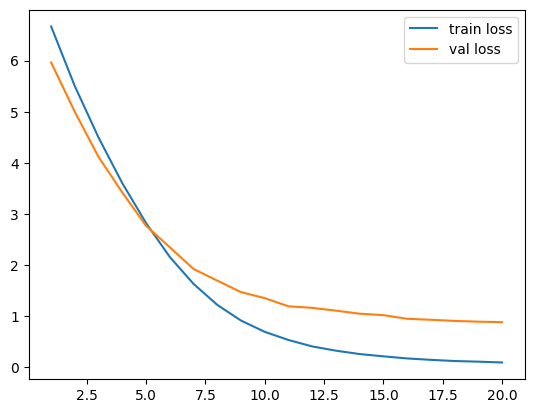

In [ ]:
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='train loss')
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='val loss')
plt.legend()
plt.show()

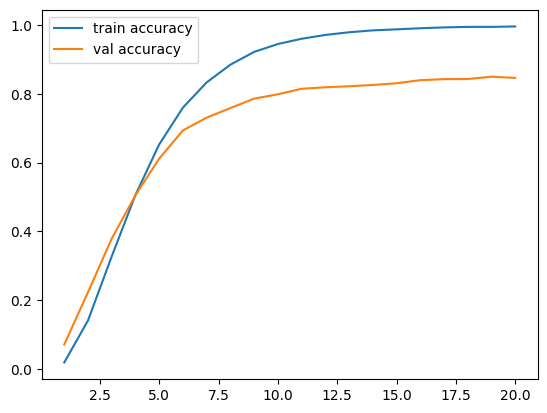

In [ ]:
plt.plot(range(1, len(train_accuracy_list) + 1), train_accuracy_list, label='train accuracy')
plt.plot(range(1, len(val_accuracy_list) + 1), val_accuracy_list, label='val accuracy')
plt.legend()
plt.show()

Еще 20 эпох, чтобы сравнить обучение этой модели с моделью на arcface loss.

In [ ]:
train(start=20)


Epoch [21/40]


100%|██████████| 188/188 [02:21<00:00,  1.33it/s]


train_loss=0.0822, train_accuracy=0.9962


100%|██████████| 24/24 [00:07<00:00,  3.01it/s]


val_loss=0.8826, val_accuracy=0.8473

Epoch [22/40]


...

val_loss=0.7139, val_accuracy=0.8710

Epoch [40/40]


100%|██████████| 188/188 [02:22<00:00,  1.32it/s]


train_loss=0.0184, train_accuracy=0.9991


100%|██████████| 24/24 [00:07<00:00,  3.31it/s]


val_loss=0.7149, val_accuracy=0.8707


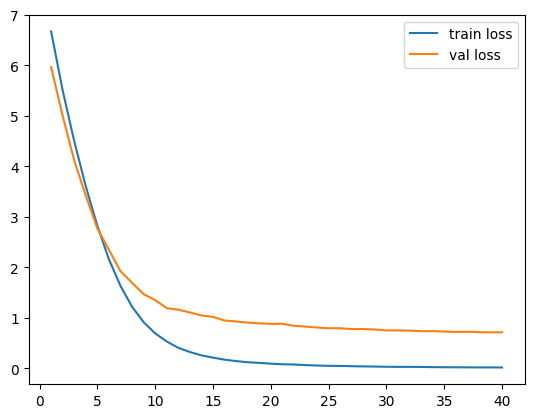

In [ ]:
plt.plot(range(1, len(train_loss_list) + 1), train_loss_list, label='train loss')
plt.plot(range(1, len(val_loss_list) + 1), val_loss_list, label='val loss')
plt.legend()
plt.show()

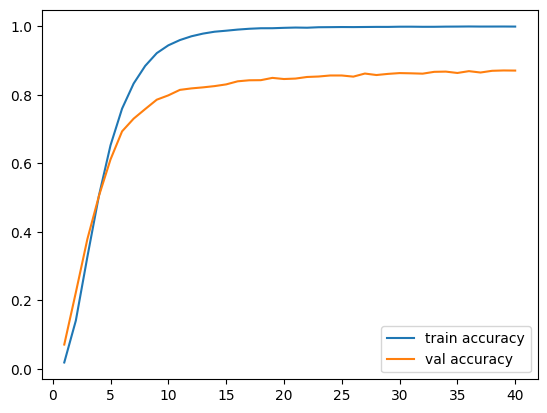

In [ ]:
plt.plot(range(1, len(train_accuracy_list) + 1), train_accuracy_list, label='train accuracy')
plt.plot(range(1, len(val_accuracy_list) + 1), val_accuracy_list, label='val accuracy')
plt.legend()
plt.show()

Посмотрим лосс и accuracy на тесте.

In [ ]:
test_loss, test_accuracy = eval_one_epoch(model, test_loader, criterion)
test_loss, test_accuracy

100%|██████████| 24/24 [00:08<00:00,  2.86it/s]


(0.6735032639503479, 0.8773333333333333)

Лучший результат был на 39 эпохе, посмотрим еще лосс и accuracy на тесте с весами 39 эпохи.

In [ ]:
model.load_state_dict(torch.load(f'{checkpoint_dir}epoch_39_best_val_accuracy.pth'))

<All keys matched successfully>

In [ ]:
test_loss, test_accuracy = eval_one_epoch(model, test_loader, criterion)
test_loss, test_accuracy

100%|██████████| 24/24 [00:08<00:00,  2.97it/s]


(0.6701579065322876, 0.8796666666666667)